In [ ]:
#This experiment is not focused on evaluating the model’s accuracy or efficiency; instead,
#it aims to determine how large we can scale the number of parameters when using Dynamax.

In [1]:
import os
import sys

os.environ['XLA_FLAGS'] = '--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['OMP_NUM_THREADS'] = '1'

import subprocess
def install_if_missing(package):
    try:
        __import__(package.split('[')[0])
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing("dynamax")
install_if_missing("tensorboard")
install_if_missing("scipy")
install_if_missing("protobuf")

import jax
import jax.numpy as jnp
from jax import random, jit
from jax.flatten_util import ravel_pytree
from flax import nnx
from flax.training import train_state
import optax
import numpy as np
from typing import List, Any
from dataclasses import dataclass, field
import time
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist as tf_mnist
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals

jax.config.update('jax_default_prng_impl', 'rbg')
jax.config.update('jax_default_matmul_precision', 'highest')

import random as py_random
GLOBAL_SEED = 42
py_random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

print("Determinism configured")
print(f"   Backend: {jax.default_backend()}")

Installing protobuf...


2025-11-30 08:04:37.343748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764489877.364907     963 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764489877.371485     963 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Determinism configured
   Backend: gpu


In [2]:

# EKF_TRAINING_SCOPE = 'output_only'  # 'output_only', 'hidden_only', or 'hidden_and_output'
# HIDDEN_SIZES = [128]             
# BATCH_SIZE = 400                    
# EKF_EPOCHS = 4                      
# PRIOR_VARIANCE = 1.0                
# DYNAMICS_SIGMA = 1e-4               
# OBSERVATION_NOISE = 3e-2            


EKF_TRAINING_SCOPE = 'hidden_and_output'  # 'output_only', 'hidden_only', or 'hidden_and_output'
HIDDEN_SIZES = [16]             
BATCH_SIZE = 1                    
EKF_EPOCHS = 1                      
PRIOR_VARIANCE = 1.0                
DYNAMICS_SIGMA = 1e-4               
OBSERVATION_NOISE = 4.5e-2            


import os
import time
import numpy as np
import jax
import jax.numpy as jnp
from jax import random, jit
from jax.flatten_util import ravel_pytree
from flax import nnx
from flax.training import train_state
import optax
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Any
from tensorflow.keras.datasets import mnist as tf_mnist


@dataclass
class Config:
    pretrain_samples: int = 10000
    pretrain_batch_size: int = 128
    finetune_samples: int = 400
    finetune_batch_size: int = BATCH_SIZE
    finetune_test_samples: int = 100
    n_test_samples: int = 2000
    shift_type: str = 'both'
    rotation_angle: float = 45.0
    contrast: float = 1.8
    brightness: float = 0.4
    hidden_sizes: List[int] = field(default_factory=lambda: HIDDEN_SIZES)
    num_classes: int = 10
    dropout_rate: float = 0.1
    pretrain_epochs: int = 10
    pretrain_lr: float = 1e-4
    ekf_epochs: int = EKF_EPOCHS
    ekf_training_scope: str = EKF_TRAINING_SCOPE
    prior_variance: float = PRIOR_VARIANCE
    dynamics_sigma: float = DYNAMICS_SIGMA
    observation_noise: float = OBSERVATION_NOISE
    print_batch_metrics: bool = False
    verify_covariance: bool = False
    seed: int = GLOBAL_SEED  # Use global seed

config = Config()


print("\n" + "="*80)
print("DEVICE SETUP")
print("="*80)
devices = jax.devices()
backend = jax.default_backend()
print(f"Backend: {backend.upper()}")
print(f"Devices: {len(devices)}")
for i, device in enumerate(devices):
    print(f"  [{i}] {device.device_kind}: {device}")
print("="*80 + "\n")


def load_mnist(normalize=True, n_train_samples=None, n_test_samples=None):
    n_train_samples = n_train_samples or config.pretrain_samples
    n_test_samples = n_test_samples or config.n_test_samples
    
    (X_train, y_train), (X_test, y_test) = tf_mnist.load_data()
    
    if normalize:
        X_train = X_train.astype(np.float32) / 255.0
        X_test = X_test.astype(np.float32) / 255.0
    
    X_train = X_train.reshape(-1, 28*28)
    X_test = X_test.reshape(-1, 28*28)
    
    rng = np.random.RandomState(config.seed)
    train_idx = rng.choice(len(X_train), n_train_samples, replace=False)
    test_idx = rng.choice(len(X_test), n_test_samples, replace=False)
    
    X_train = jnp.array(X_train[train_idx], dtype=jnp.float32)
    y_train = jnp.array(y_train[train_idx], dtype=jnp.int32)
    X_test = jnp.array(X_test[test_idx], dtype=jnp.float32)
    y_test = jnp.array(y_test[test_idx], dtype=jnp.int32)
    
    return X_train, y_train, X_test, y_test

def apply_domain_shift(X, shift_type='both', contrast=1.8, brightness=0.4, rotation_angle=45):
    X_reshaped = X.reshape(-1, 28, 28)
    
    if shift_type == 'brightness_contrast':
        X_shifted = np.clip(((X_reshaped - 0.5) * contrast + 0.5) + brightness, 0, 1)
    elif shift_type == 'rotation':
        from scipy.ndimage import rotate
        X_shifted = np.array([rotate(img, rotation_angle, reshape=False, order=1, 
                                    mode='constant', cval=0.0) for img in X_reshaped])
    elif shift_type == 'both':
        from scipy.ndimage import rotate
        X_rotated = np.array([rotate(img, rotation_angle, reshape=False, order=1, 
                                    mode='constant', cval=0.0) for img in X_reshaped])
        X_shifted = np.clip(((X_rotated - 0.5) * contrast + 0.5) + brightness, 0, 1)
    else:
        X_shifted = X_reshaped
    
    return jnp.array(X_shifted.reshape(-1, 28*28), dtype=jnp.float32)

def stratified_sample(X, y, n_samples, n_classes=10, seed=42):
    n_per_class = n_samples // n_classes
    rng = np.random.RandomState(seed)
    
    X_np = np.array(X)
    y_np = np.array(y)
    
    X_sampled, y_sampled = [], []
    
    for class_label in range(n_classes):
        class_indices = np.where(y_np == class_label)[0]
        
        if len(class_indices) < n_per_class:
            selected_indices = class_indices
        else:
            selected_indices = rng.choice(class_indices, n_per_class, replace=False)
        
        X_sampled.append(X_np[selected_indices])
        y_sampled.append(y_np[selected_indices])
    
    X_sampled = np.concatenate(X_sampled, axis=0)
    y_sampled = np.concatenate(y_sampled, axis=0)
    
    shuffle_idx = rng.permutation(len(X_sampled))
    X_sampled = X_sampled[shuffle_idx]
    y_sampled = y_sampled[shuffle_idx]
    
    return jnp.array(X_sampled, dtype=jnp.float32), jnp.array(y_sampled, dtype=jnp.int32)




DEVICE SETUP
Backend: GPU
Devices: 1
  [0] Tesla P100-PCIE-16GB: cuda:0



In [3]:

class MLP(nnx.Module):
    def __init__(self, hidden_sizes: List[int], num_classes: int, rngs: nnx.Rngs):
        self.hidden_sizes = hidden_sizes
        self.num_classes = num_classes
        self.layers = []
        
        in_features = 28 * 28
        for i, hidden_size in enumerate(hidden_sizes):
            self.layers.append(nnx.Linear(in_features, hidden_size, rngs=rngs))
            in_features = hidden_size
        
        self.output = nnx.Linear(in_features, num_classes, rngs=rngs)
        self.dropout = nnx.Dropout(rate=config.dropout_rate, rngs=rngs)
    
    def __call__(self, x, training: bool = False):
        for layer in self.layers:
            x = layer(x)
            #x = nnx.relu(x)
            x = nnx.leaky_relu(x, negative_slope=0.1)
            if training:
                x = self.dropout(x)
        return self.output(x)
    
    def extract_features(self, x):
        for layer in self.layers:
            x = layer(x)
            x = nnx.relu(x)
        return x

@jit
def cross_entropy_loss(logits, labels):
    one_hot = jax.nn.one_hot(labels, config.num_classes)
    return -jnp.mean(jnp.sum(one_hot * jax.nn.log_softmax(logits), axis=-1))

@jit
def compute_accuracy(logits, labels):
    predictions = jnp.argmax(logits, axis=-1)
    return jnp.mean(predictions == labels)

# TRAIN STATE
class TrainState(train_state.TrainState):
    graphdef: Any = None

def create_train_state(model, learning_rate):
    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    tx = optax.adam(learning_rate)
    
    def apply_fn(params, x, training=False):
        model_copy = nnx.merge(graphdef, params, other_states)
        return model_copy(x, training=training)
    
    return TrainState.create(
        apply_fn=apply_fn,
        params=params,
        tx=tx,
        graphdef=graphdef
    )

# COVARIANCE MONITORING
def verify_covariance_matrix(P, name="P", step=0):
    if not config.verify_covariance:
        return
    
    is_symmetric = jnp.allclose(P, P.T, atol=1e-6)
    eigenvalues = jnp.linalg.eigvalsh(P)
    min_eigenvalue = jnp.min(eigenvalues)
    is_psd = min_eigenvalue >= -1e-6
    
    trace = jnp.trace(P)
    frobenius_norm = jnp.linalg.norm(P, 'fro')
    
    if step % 50 == 0:
        print(f"    [{name} @step {step}] Symmetric: {is_symmetric}, PSD: {is_psd}, "
              f"Tr: {trace:.2e}, ||P||_F: {frobenius_norm:.2e}, λ_min: {min_eigenvalue:.2e}")
    
    if not is_symmetric:
        print(f"    WARNING: {name} is not symmetric at step {step}!")
    if not is_psd:
        print(f"    WARNING: {name} is not PSD at step {step}! Min eigenvalue: {min_eigenvalue:.2e}")


# PARAMETER CALCULATOR
def calculate_params_and_memory():
    input_size = 28 * 28
    output_size = config.num_classes
    hidden_sizes = config.hidden_sizes
    
    params = {}
    in_features = input_size
    for i, hidden_size in enumerate(hidden_sizes):
        layer_params = in_features * hidden_size + hidden_size
        params[f'hidden_layer_{i}'] = layer_params
        in_features = hidden_size
    
    output_params = in_features * output_size + output_size
    params['output'] = output_params
    
    total_params = sum(params.values())
    
    output_only_params = params['output']
    hidden_params = sum(v for k, v in params.items() if 'hidden' in k)
    all_params = total_params
    
    def mem_gb(n):
        return (n ** 2 * 4) / (1024 ** 3)
    
    print("\n" + "="*80)
    print("PARAMETER & MEMORY CALCULATION")
    print("="*80)
    print(f"\nArchitecture: Input({input_size}) → Hidden{hidden_sizes} → Output({output_size})")
    print(f"\nParameters per layer:")
    for name, count in params.items():
        print(f"  {name:20s}: {count:>10,}")
    print(f"  {'TOTAL':20s}: {total_params:>10,}")
    
    print(f"\nTraining Scopes:")
    print(f"  1. OUTPUT ONLY:")
    print(f"     Params: {output_only_params:,}, Memory: {mem_gb(output_only_params):.4f} GB")
    print(f"  2. HIDDEN ONLY:")
    print(f"     Params: {hidden_params:,}, Memory: {mem_gb(hidden_params):.4f} GB")
    print(f"  3. HIDDEN + OUTPUT:")
    print(f"     Params: {all_params:,}, Memory: {mem_gb(all_params):.4f} GB")
    print("="*80 + "\n")
    
    return params, total_params



In [4]:
# PRETRAINING
def pretrain_model(X_train, y_train, X_test, y_test):
    print("\n" + "="*80)
    print("PRETRAINING")
    print("="*80)
    
    rng = nnx.Rngs(config.seed)
    model = MLP(config.hidden_sizes, config.num_classes, rng)
    
    all_params = nnx.state(model, nnx.Param)
    total_params = sum(v.size for v in jax.tree.leaves(all_params))
    print(f"Total model parameters: {total_params:,}")
    
    state = create_train_state(model, config.pretrain_lr)
    
    @jit
    def train_step(state, batch):
        x, y = batch
        def loss_fn(params):
            logits = state.apply_fn(params, x, training=True)
            return cross_entropy_loss(logits, y)
        
        loss, grads = jax.value_and_grad(loss_fn)(state.params)
        state = state.apply_gradients(grads=grads)
        
        logits = state.apply_fn(state.params, x, training=False)
        acc = compute_accuracy(logits, y)
        return state, loss, acc
    
    @jit
    def eval_step(state, batch):
        x, y = batch
        logits = state.apply_fn(state.params, x, training=False)
        loss = cross_entropy_loss(logits, y)
        acc = compute_accuracy(logits, y)
        return loss, acc
    
    n_batches = int(np.ceil(len(X_train) / config.pretrain_batch_size))
    
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + config.seed)
        perm = random.permutation(key, len(X_train))
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]
        
        epoch_loss = 0.0
        epoch_acc = 0.0
        
        for i in range(n_batches):
            start_idx = i * config.pretrain_batch_size
            end_idx = min((i + 1) * config.pretrain_batch_size, len(X_train))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            
            state, loss, acc = train_step(state, (batch_x, batch_y))
            epoch_loss += loss
            epoch_acc += acc
        
        epoch_loss /= n_batches
        epoch_acc /= n_batches
        
        test_loss, test_acc = eval_step(state, (X_test, y_test))
        
        print(f"Epoch {epoch+1}/{config.pretrain_epochs} | "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
    
    # Reconstruct final model
    graphdef, _, other_states = nnx.split(model, nnx.Param, ...)
    final_model = nnx.merge(graphdef, state.params, other_states)
    
    return final_model, float(test_acc), float(test_loss)



In [5]:
import jax
import jax.numpy as jnp
from jax import lax, jacfwd
from typing import NamedTuple, Optional, Callable
from dynamax.utils.utils import psd_solve
import functools


# HELPER FUNCTIONS
def _get_params(x, dim, t):
    return x[t] if x.ndim == dim + 1 else x

def _process_fn(f, u):
    return (lambda w, uu: f(w)) if u is None else f

def _process_input(x, T):
    return jnp.zeros((T,)) if x is None else x

# GAUSSIAN INTEGRATION HELPERS (for _predict and _condition_on)
def _predict(prior_mean, prior_cov, dynamics_func, dynamics_cov, inpt, 
             gaussian_expec, gaussian_crosscov):
    """
    Predict step: computes predicted mean, covariance, and cross-covariance.
    
    Uses the gaussian integration methods from inf_params.
    """
    dynamics_fn = lambda x: dynamics_func(x, inpt)
    identity_fn = lambda x: x
    
    mu_pred = gaussian_expec(dynamics_fn, prior_mean, prior_cov)
    Sigma_pred = gaussian_crosscov(dynamics_fn, dynamics_fn, prior_mean, prior_cov) + dynamics_cov
    cross_pred = gaussian_crosscov(identity_fn, dynamics_fn, prior_mean, prior_cov)
    
    return mu_pred, Sigma_pred, cross_pred

def _condition_on(prior_mean, prior_cov, emission_mean, emission_cov, inpt, emission,
                  gaussian_expec, gaussian_crosscov, num_iter, emission_dist):
    """
    Update step: conditions on observation using gaussian integration methods.
    
    Iteratively re-linearizes around the posterior (num_iter times).
    """
    m_Y = lambda x: emission_mean(x, inpt)
    Cov_Y = lambda x: emission_cov(x, inpt)
    identity_fn = lambda x: x
    
    def _step(carry, _):
        prior_mean, prior_cov = carry
        
        # Predicted observation
        yhat = gaussian_expec(m_Y, prior_mean, prior_cov)
        
        # Innovation covariance: S = E[R] + Cov[h(x), h(x)]
        S = gaussian_expec(Cov_Y, prior_mean, prior_cov) + \
            gaussian_crosscov(m_Y, m_Y, prior_mean, prior_cov)
        
        # Log likelihood
        log_likelihood = emission_dist(yhat, S).log_prob(jnp.atleast_1d(emission)).sum()
        
        # Cross covariance: C = Cov[x, h(x)]
        C = gaussian_crosscov(identity_fn, m_Y, prior_mean, prior_cov)
        
        # Kalman gain: K = C S^{-1}
        K = psd_solve(S, C.T).T
        
        # Posterior
        posterior_mean = prior_mean + K @ (emission - yhat)
        posterior_cov = prior_cov - K @ S @ K.T
        
        return (posterior_mean, posterior_cov), log_likelihood
    
    # Iterate re-linearization
    carry = (prior_mean, prior_cov)
    (mu_cond, Sigma_cond), lls = lax.scan(_step, carry, jnp.arange(num_iter))
    
    return lls[0], mu_cond, Sigma_cond

# POSTERIOR OUTPUT
class SimplePosterior(NamedTuple):
    marginal_loglik: float
    filtered_mean: jnp.ndarray       # (state_dim,)
    filtered_covariance: jnp.ndarray  # (state_dim, state_dim)

# MAIN FILTER FUNCTION
def cmgf_final_only(
    model_params,
    inf_params,  # CMGFIntegrals (EKFIntegrals/UKFIntegrals/GHKFIntegrals)
    emissions: jnp.ndarray,
    inputs: Optional[jnp.ndarray] = None,
    num_iter: int = 1
):
    num_timesteps = len(emissions)
    
    f = model_params.dynamics_function
    m_Y = model_params.emission_mean_function
    Cov_Y = model_params.emission_cov_function
    
    f, m_Y, Cov_Y = (_process_fn(fn, inputs) for fn in (f, m_Y, Cov_Y))
    inputs = _process_input(inputs, num_timesteps)
    
    # Extract Gaussian integration methods from inf_params
    # These are DEFINED in EKFIntegrals/UKFIntegrals/GHKFIntegrals
    g_ev = inf_params.gaussian_expectation      
    g_cov = inf_params.gaussian_cross_covariance  
    
    # Emission distribution
    emission_dist = model_params.emission_dist
    
    def _step(carry, t):
        """One filter step: predict → update → predict"""
        # Carry includes last filtered state to extract at the end
        ll, pred_mean, pred_cov, last_filt_mean, last_filt_cov = carry
        
        # Get parameters for timestep t
        Q = _get_params(model_params.dynamics_covariance, 2, t)
        u = inputs[t]
        y = emissions[t]
        
        # condition on observation
        log_likelihood, filtered_mean, filtered_cov = \
            _condition_on(pred_mean, pred_cov, m_Y, Cov_Y, u, y, 
                         g_ev, g_cov, num_iter, emission_dist)
        ll += log_likelihood
        
        # PREDICT: next state
        pred_mean, pred_cov, _ = _predict(filtered_mean, filtered_cov, f, Q, u, g_ev, g_cov)
        
        # Store this filtered state
        return (ll, pred_mean, pred_cov, filtered_mean, filtered_cov), None
    
    # Initialize
    carry = (0.0, 
             model_params.initial_mean, 
             model_params.initial_covariance,
             model_params.initial_mean,  
             model_params.initial_covariance) 
    
    # Run filter
    (ll_final, _, _, final_filtered_mean, final_filtered_cov), _ = \
        lax.scan(_step, carry, jnp.arange(num_timesteps))
    
    return SimplePosterior(
        marginal_loglik=ll_final,
        filtered_mean=final_filtered_mean,
        filtered_covariance=final_filtered_cov
    )

In [6]:
# EKF UPDATE
def ekf_update(model, X_batch, y_batch, P_previous=None, training_scope='hidden_and_output', step=0):
    trainable_dict = {}
    
    if training_scope == 'output_only':
        output_state = nnx.state(model.output, nnx.Param)
        trainable_dict = output_state
        
    elif training_scope == 'hidden_only':
        for i, layer in enumerate(model.layers):
            layer_state = nnx.state(layer, nnx.Param)
            trainable_dict[f'layer_{i}'] = layer_state
        
    elif training_scope == 'hidden_and_output':
        for i, layer in enumerate(model.layers):
            layer_state = nnx.state(layer, nnx.Param)
            trainable_dict[f'layer_{i}'] = layer_state
        output_state = nnx.state(model.output, nnx.Param)
        trainable_dict['output'] = output_state
    
    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size
    
    if step == 0:
        print(f"\n  [EKF] Training scope: {training_scope}")
        print(f"  [EKF] Trainable parameters: {state_dim:,}")
        covariance_memory_gb = (state_dim ** 2) * 4 / (1024 ** 3)
        print(f"  [EKF] Covariance matrix memory: ~{covariance_memory_gb:.2f} GB")
        # DEBUGGING
        #print(f"  [DEBUG] Params checksum: {jnp.sum(jnp.abs(flat_params)):.10f}")
        #print(f"  [DEBUG] X_batch checksum: {jnp.sum(jnp.abs(X_batch)):.10f}")
        
    
    def forward_fn(params_flat, x):
        params = unflatten_fn(params_flat)
        
        if training_scope == 'output_only':
            output_graphdef, _, output_other = nnx.split(model.output, nnx.Param, ...)
            output_temp = nnx.merge(output_graphdef, params, output_other)
            features = model.extract_features(x)
            logits = output_temp(features)
            
        elif training_scope == 'hidden_only':
            x_temp = x
            for i, layer in enumerate(model.layers):
                layer_graphdef, _, layer_other = nnx.split(layer, nnx.Param, ...)
                layer_temp = nnx.merge(layer_graphdef, params[f'layer_{i}'], layer_other)
                x_temp = layer_temp(x_temp)
                x_temp = nnx.relu(x_temp)
            logits = model.output(x_temp)
            
        elif training_scope == 'hidden_and_output':
            x_temp = x
            for i, layer in enumerate(model.layers):
                layer_graphdef, _, layer_other = nnx.split(layer, nnx.Param, ...)
                layer_temp = nnx.merge(layer_graphdef, params[f'layer_{i}'], layer_other)
                x_temp = layer_temp(x_temp)
                x_temp = nnx.relu(x_temp)
            
            output_graphdef, _, output_other = nnx.split(model.output, nnx.Param, ...)
            output_temp = nnx.merge(output_graphdef, params['output'], output_other)
            logits = output_temp(x_temp)
        
        return jax.nn.softmax(logits)
    
    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance
        print(f"  [EKF] Initializing P = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        if step % 50 == 0:
            verify_covariance_matrix(P_previous, "P_prev", step)
    
    params = ParamsGGSSM(
        initial_mean=flat_params,
        initial_covariance=initial_covariance,
        dynamics_function=lambda w, x: w,
        dynamics_covariance=jnp.eye(state_dim) * config.dynamics_sigma,
        emission_mean_function=forward_fn,
        emission_cov_function=lambda w, x: jnp.diag(forward_fn(w, x) * (1 - forward_fn(w, x))) + 
                                           config.observation_noise * jnp.eye(config.num_classes)
    )
    
    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch
    
    ekf_post = conditional_moments_gaussian_filter(params, EKFIntegrals(), emissions, inputs)
    #ekf_post = cmgf_final_only(params, EKFIntegrals(), emissions, inputs)
    
    #print(ekf_post.filtered_covariances.shape)
    #print(ekf_post.filtered_means.shape)

    updated_params_flat = ekf_post.filtered_means[-1]
    updated_covariance = ekf_post.filtered_covariances[-1]

    # updated_params_flat = ekf_post.filtered_mean
    # updated_covariance = ekf_post.filtered_covariance
    
    if step % 50 == 0:
        verify_covariance_matrix(updated_covariance, "P_updated", step)
    
    updated_params = unflatten_fn(updated_params_flat)
    
    if training_scope == 'output_only':
        nnx.update(model.output, updated_params)
    elif training_scope == 'hidden_only':
        for i, layer in enumerate(model.layers):
            nnx.update(layer, updated_params[f'layer_{i}'])
    elif training_scope == 'hidden_and_output':
        for i, layer in enumerate(model.layers):
            nnx.update(layer, updated_params[f'layer_{i}'])
        nnx.update(model.output, updated_params['output'])
    
    return model, updated_covariance

# EKF FINE-TUNING
def ekf_finetune(model, X_train, y_train, X_test, y_test, training_scope):
    print(f"\n{'='*80}")
    print(f"EKF FINE-TUNING: {training_scope.upper()}")
    print(f"{'='*80}")
    
    model = nnx.clone(model)
    
    losses, accs = [], []
    test_accs_per_epoch = []
    test_losses_per_epoch = []
    traces_per_epoch = []
    
    P = None
    n_batches = int(np.ceil(len(X_train) / config.finetune_batch_size))
    total_steps = 0
    
    start_time = time.time()
    
    for epoch in range(config.ekf_epochs):
        key = random.PRNGKey(epoch + config.seed + 1000)
        perm = random.permutation(key, len(X_train))
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]
        
        epoch_loss = 0.0
        epoch_acc = 0.0
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * config.finetune_batch_size
            end_idx = min((batch_idx + 1) * config.finetune_batch_size, len(X_train))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            
            model, P = ekf_update(model, batch_x, batch_y, P, training_scope, step=total_steps)
            
            logits = model(batch_x, training=False)
            loss = float(cross_entropy_loss(logits, batch_y))
            acc = float(compute_accuracy(logits, batch_y))
            
            losses.append(loss)
            accs.append(acc)
            epoch_loss += loss
            epoch_acc += acc
            
            if config.print_batch_metrics:
                trace_P = float(jnp.trace(P))
                print(f"  Epoch {epoch+1}/{config.ekf_epochs} | "
                      f"Batch {batch_idx+1}/{n_batches} | "
                      f"Loss: {loss:.4f} | Acc: {acc:.4f} | "
                      f"Tr(P): {trace_P:.2e}")
            
            total_steps += 1


            # if epoch == 0 and batch_idx == 0:
            #     # Visualize P structure
            #     plt.figure(figsize=(8, 8))
            #     plt.imshow(np.log10(np.abs(P) + 1e-10), cmap='viridis')
            #     plt.colorbar(label='log10(|P_ij|)')
            #     plt.title('Covariance Matrix Structure (log scale)')
            #     plt.xlabel('Parameter j')
            #     plt.ylabel('Parameter i')
            #     plt.tight_layout()
            #     plt.savefig('covariance_structure.png', dpi=150)
            #     plt.show()
                
            #     # Check sparsity
            #     nonzero_elements = np.count_nonzero(np.abs(P) > 1e-10)
            #     total_elements = P.size
            #     sparsity = 1 - (nonzero_elements / total_elements)
            #     print(f"\n  [P Structure]")
            #     print(f"    Non-zero elements: {nonzero_elements:,} / {total_elements:,}")
            #     print(f"    Sparsity: {sparsity*100:.2f}%")


        epoch_loss /= n_batches
        epoch_acc /= n_batches
        
        test_logits = model(X_test, training=False)
        test_acc = float(compute_accuracy(test_logits, y_test))
        test_loss = float(cross_entropy_loss(test_logits, y_test))
        
        test_accs_per_epoch.append(test_acc)
        test_losses_per_epoch.append(test_loss)
        trace_P = float(jnp.trace(P))
        traces_per_epoch.append(trace_P)
        
        print(f"\n  Epoch {epoch+1}/{config.ekf_epochs} Summary:")
        print(f"    Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
        print(f"    Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
        print(f"    Tr(P): {trace_P:.2e}\n")
    
    training_time = time.time() - start_time
    
    test_logits = model(X_test, training=False)
    final_test_acc = float(compute_accuracy(test_logits, y_test))
    final_test_loss = float(cross_entropy_loss(test_logits, y_test))
    
    results = {
        'model': model,
        'covariance': P,
        'losses': losses,
        'accs': accs,
        'test_accs_per_epoch': test_accs_per_epoch,
        'test_losses_per_epoch': test_losses_per_epoch,
        'traces_per_epoch': traces_per_epoch,
        'final_test_acc': final_test_acc,
        'final_test_loss': final_test_loss,
        'training_time': training_time
    }
    
    return results



In [7]:
# VISUALIZATION
def plot_results(results, baseline_acc, title_suffix=""):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    axes[0, 0].plot(results['losses'], linewidth=2)
    axes[0, 0].set_xlabel('Batch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(results['accs'], linewidth=2)
    axes[0, 1].set_xlabel('Batch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Training Accuracy')
    axes[0, 1].grid(True, alpha=0.3)
    
    epochs = range(1, len(results['test_accs_per_epoch']) + 1)
    axes[0, 2].plot(epochs, results['test_accs_per_epoch'], marker='o', 
                    linewidth=2, markersize=10)
    axes[0, 2].axhline(y=baseline_acc, color='r', linestyle='--', 
                       label=f'Baseline: {baseline_acc:.3f}')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Test Accuracy')
    axes[0, 2].set_title('Test Accuracy per Epoch')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    axes[1, 0].plot(epochs, results['test_losses_per_epoch'], marker='s',
                    linewidth=2, markersize=10, color='orange')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Test Loss')
    axes[1, 0].set_title('Test Loss per Epoch')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(epochs, results['traces_per_epoch'], marker='^',
                    linewidth=2, markersize=10, color='green')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Trace(P)')
    axes[1, 1].set_title('Covariance Trace')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[1, 2].axis('off')
    summary_text = f"""
    FINAL RESULTS {title_suffix}
    {'='*40}
    
    Final Test Accuracy: {results['final_test_acc']:.4f}
    Final Test Loss:     {results['final_test_loss']:.4f}
    Baseline Accuracy:   {baseline_acc:.4f}
    
    Improvement: {(results['final_test_acc'] - baseline_acc):.4f}
    
    Training Time: {results['training_time']:.2f}s
    Epochs: {len(results['test_accs_per_epoch'])}
    Batches: {len(results['losses'])}
    
    Final Tr(P): {results['traces_per_epoch'][-1]:.2e}
    """
    axes[1, 2].text(0.1, 0.5, summary_text, fontsize=11, 
                    family='monospace', verticalalignment='center')
    
    plt.suptitle(f'EKF Fine-Tuning Results: {title_suffix}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()



In [8]:

# MAIN EXPERIMENT
print(f"\n{'='*80}")
print("EKF HIDDEN LAYER EXPERIMENT")
print(f"{'='*80}")
print(f"Configuration:")
print(f"  Hidden sizes: {config.hidden_sizes}")
print(f"  Training scope: {config.ekf_training_scope}")
print(f"  Batch size: {config.finetune_batch_size}")
print(f"  EKF epochs: {config.ekf_epochs}")

params_dict, total_params = calculate_params_and_memory()

X_train_full, y_train_full, X_test_full, y_test_full = load_mnist(
    normalize=True, n_train_samples=60000, n_test_samples=10000
)

X_train_pretrain, y_train_pretrain = stratified_sample(
    X_train_full, y_train_full, config.pretrain_samples, seed=config.seed
)
X_test_pretrain, y_test_pretrain = stratified_sample(
    X_test_full, y_test_full, config.n_test_samples, seed=config.seed + 1
)

X_train_finetune, y_train_finetune = stratified_sample(
    X_train_full, y_train_full, config.finetune_samples, seed=config.seed + 2
)
X_train_finetune_shifted = apply_domain_shift(
    X_train_finetune, config.shift_type, config.contrast, 
    config.brightness, config.rotation_angle
)

X_test_finetune, y_test_finetune = stratified_sample(
    X_test_full, y_test_full, config.finetune_test_samples, seed=config.seed + 3
)
X_test_finetune_shifted = apply_domain_shift(
    X_test_finetune, config.shift_type, config.contrast,
    config.brightness, config.rotation_angle
)

print(f"\nData prepared:")
print(f"  Pretrain: {X_train_pretrain.shape[0]} samples")
print(f"  Finetune: {X_train_finetune_shifted.shape[0]} samples (shifted)")
print(f"  Test: {X_test_finetune_shifted.shape[0]} samples (shifted)")

pretrained_model, _, _ = pretrain_model(
    X_train_pretrain, y_train_pretrain, 
    X_test_pretrain, y_test_pretrain
)

test_logits = pretrained_model(X_test_finetune_shifted, training=False)
baseline_acc = float(compute_accuracy(test_logits, y_test_finetune))
baseline_loss = float(cross_entropy_loss(test_logits, y_test_finetune))

print(f"\n{'='*80}")
print(f"BASELINE (pretrained on shifted data)")
print(f"{'='*80}")
print(f"Accuracy: {baseline_acc:.4f}")
print(f"Loss: {baseline_loss:.4f}")




EKF HIDDEN LAYER EXPERIMENT
Configuration:
  Hidden sizes: [16]
  Training scope: hidden_and_output
  Batch size: 1
  EKF epochs: 1

PARAMETER & MEMORY CALCULATION

Architecture: Input(784) → Hidden[16] → Output(10)

Parameters per layer:
  hidden_layer_0      :     12,560
  output              :        170
  TOTAL               :     12,730

Training Scopes:
  1. OUTPUT ONLY:
     Params: 170, Memory: 0.0001 GB
  2. HIDDEN ONLY:
     Params: 12,560, Memory: 0.5877 GB
  3. HIDDEN + OUTPUT:
     Params: 12,730, Memory: 0.6037 GB


Data prepared:
  Pretrain: 10000 samples
  Finetune: 400 samples (shifted)
  Test: 100 samples (shifted)

PRETRAINING
Total model parameters: 12,730
Epoch 1/10 | Train Loss: 2.1947 | Train Acc: 0.2451 | Test Loss: 2.0729 | Test Acc: 0.3540
Epoch 2/10 | Train Loss: 1.9721 | Train Acc: 0.4094 | Test Loss: 1.8198 | Test Acc: 0.4910
Epoch 3/10 | Train Loss: 1.7376 | Train Acc: 0.5437 | Test Loss: 1.5891 | Test Acc: 0.6300
Epoch 4/10 | Train Loss: 1.5382 | Train A

### CMGF Results


EKF FINE-TUNING: HIDDEN_AND_OUTPUT

  [EKF] Training scope: hidden_and_output
  [EKF] Trainable parameters: 12,730
  [EKF] Covariance matrix memory: ~0.60 GB
  [EKF] Initializing P = 1.0 × I (12730×12730)

  Epoch 1/1 Summary:
    Train Loss: 0.2083 | Train Acc: 0.9725
    Test Loss:  0.6536 | Test Acc:  0.7500
    Tr(P): 1.21e+04


FINAL RESULTS
Training scope: hidden_and_output
Final test accuracy: 0.7500
Final test loss: 0.6536
Improvement: 0.5200
Training time: 854.69s


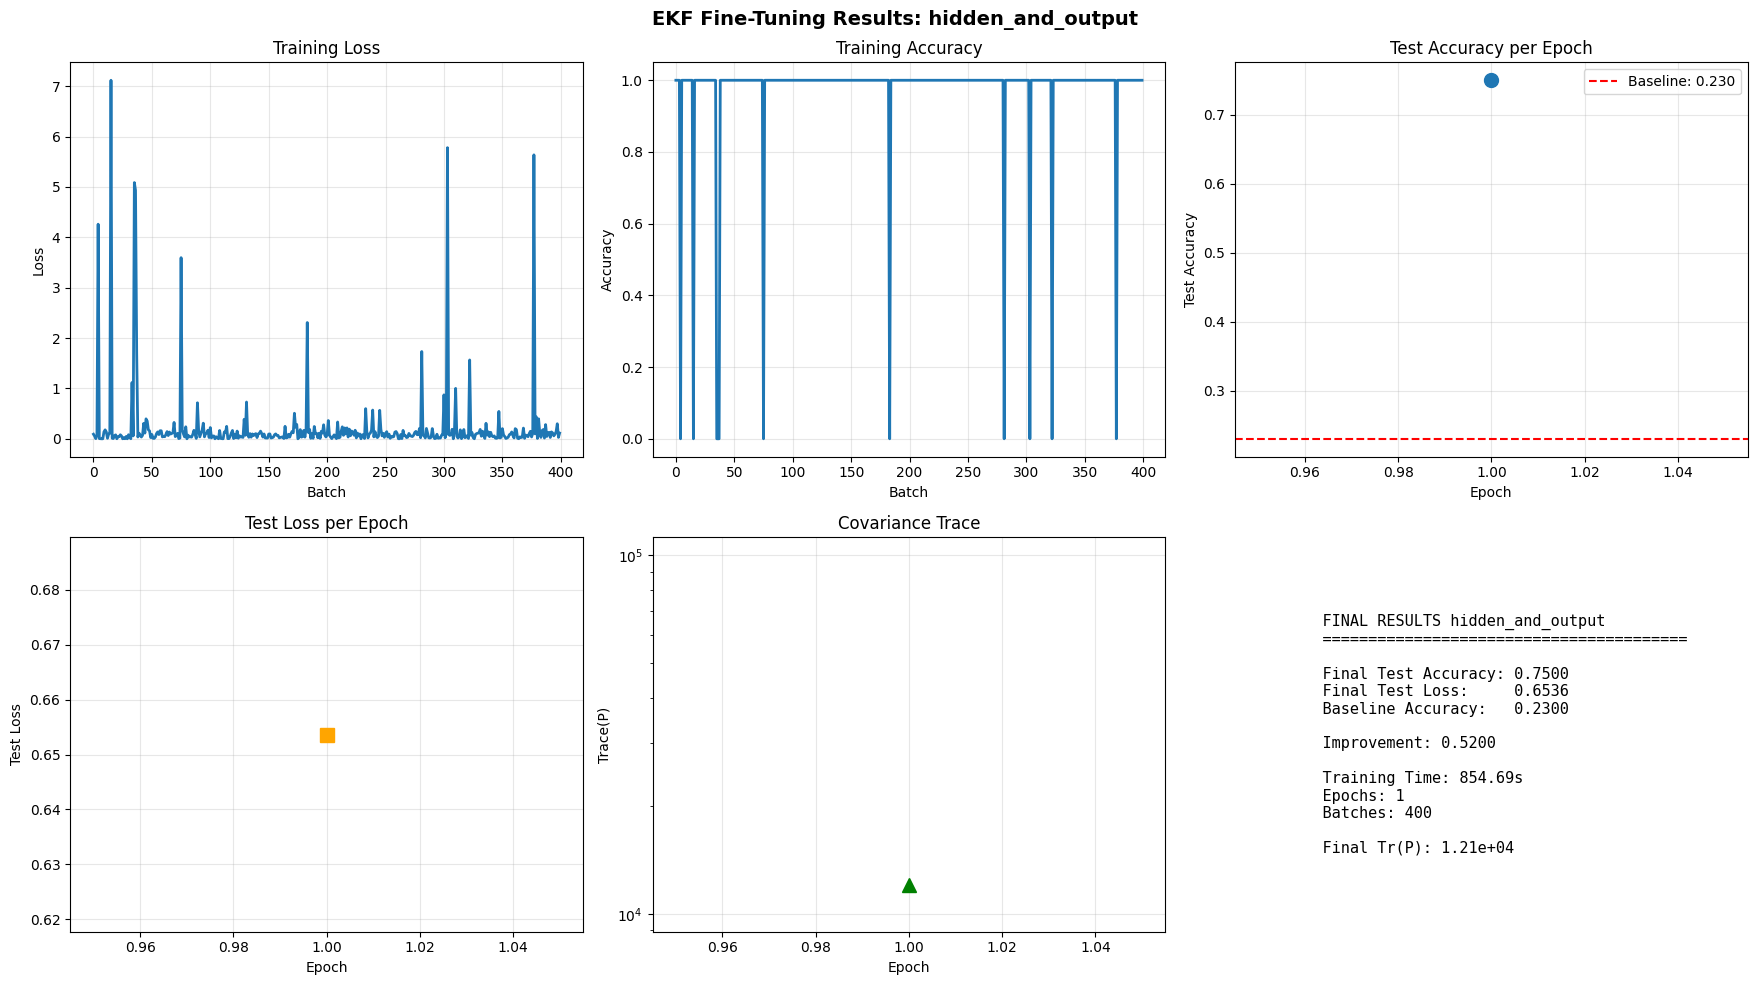

In [9]:
results = ekf_finetune(
    pretrained_model,
    X_train_finetune_shifted, y_train_finetune,
    X_test_finetune_shifted, y_test_finetune,
    training_scope=config.ekf_training_scope
)

print(f"\n{'='*80}")
print(f"FINAL RESULTS")
print(f"{'='*80}")
print(f"Training scope: {config.ekf_training_scope}")
print(f"Final test accuracy: {results['final_test_acc']:.4f}")
print(f"Final test loss: {results['final_test_loss']:.4f}")
print(f"Improvement: {(results['final_test_acc'] - baseline_acc):.4f}")
print(f"Training time: {results['training_time']:.2f}s")

plot_results(results, baseline_acc, title_suffix=config.ekf_training_scope)

### CMGF Wrapper Class Results

In [16]:
EKF_TRAINING_SCOPE = 'hidden_and_output'  # 'output_only', 'hidden_only', or 'hidden_and_output'
HIDDEN_SIZES = [20]             
BATCH_SIZE = 1                    
EKF_EPOCHS = 1                      
PRIOR_VARIANCE = 1.0                
DYNAMICS_SIGMA = 1e-4               
OBSERVATION_NOISE = 4.5e-2

@dataclass
class Config:
    pretrain_samples: int = 10000
    pretrain_batch_size: int = 128
    finetune_samples: int = 400
    finetune_batch_size: int = BATCH_SIZE
    finetune_test_samples: int = 100
    n_test_samples: int = 2000
    shift_type: str = 'both'
    rotation_angle: float = 45.0
    contrast: float = 1.8
    brightness: float = 0.4
    hidden_sizes: List[int] = field(default_factory=lambda: HIDDEN_SIZES)
    num_classes: int = 10
    dropout_rate: float = 0.1
    pretrain_epochs: int = 10
    pretrain_lr: float = 1e-4
    ekf_epochs: int = EKF_EPOCHS
    ekf_training_scope: str = EKF_TRAINING_SCOPE
    prior_variance: float = PRIOR_VARIANCE
    dynamics_sigma: float = DYNAMICS_SIGMA
    observation_noise: float = OBSERVATION_NOISE
    print_batch_metrics: bool = False
    verify_covariance: bool = False
    seed: int = GLOBAL_SEED  # Use global seed

config = Config()

In [17]:
# EKF UPDATE
def ekf_update(model, X_batch, y_batch, P_previous=None, training_scope='hidden_and_output', step=0):
    trainable_dict = {}
    
    if training_scope == 'output_only':
        output_state = nnx.state(model.output, nnx.Param)
        trainable_dict = output_state
        
    elif training_scope == 'hidden_only':
        for i, layer in enumerate(model.layers):
            layer_state = nnx.state(layer, nnx.Param)
            trainable_dict[f'layer_{i}'] = layer_state
        
    elif training_scope == 'hidden_and_output':
        for i, layer in enumerate(model.layers):
            layer_state = nnx.state(layer, nnx.Param)
            trainable_dict[f'layer_{i}'] = layer_state
        output_state = nnx.state(model.output, nnx.Param)
        trainable_dict['output'] = output_state
    
    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size
    
    if step == 0:
        print(f"\n  [EKF] Training scope: {training_scope}")
        print(f"  [EKF] Trainable parameters: {state_dim:,}")
        covariance_memory_gb = (state_dim ** 2) * 4 / (1024 ** 3)
        print(f"  [EKF] Covariance matrix memory: ~{covariance_memory_gb:.2f} GB")
        # DEBUGGING
        #print(f"  [DEBUG] Params checksum: {jnp.sum(jnp.abs(flat_params)):.10f}")
        #print(f"  [DEBUG] X_batch checksum: {jnp.sum(jnp.abs(X_batch)):.10f}")
        
    
    def forward_fn(params_flat, x):
        params = unflatten_fn(params_flat)
        
        if training_scope == 'output_only':
            output_graphdef, _, output_other = nnx.split(model.output, nnx.Param, ...)
            output_temp = nnx.merge(output_graphdef, params, output_other)
            features = model.extract_features(x)
            logits = output_temp(features)
            
        elif training_scope == 'hidden_only':
            x_temp = x
            for i, layer in enumerate(model.layers):
                layer_graphdef, _, layer_other = nnx.split(layer, nnx.Param, ...)
                layer_temp = nnx.merge(layer_graphdef, params[f'layer_{i}'], layer_other)
                x_temp = layer_temp(x_temp)
                x_temp = nnx.relu(x_temp)
            logits = model.output(x_temp)
            
        elif training_scope == 'hidden_and_output':
            x_temp = x
            for i, layer in enumerate(model.layers):
                layer_graphdef, _, layer_other = nnx.split(layer, nnx.Param, ...)
                layer_temp = nnx.merge(layer_graphdef, params[f'layer_{i}'], layer_other)
                x_temp = layer_temp(x_temp)
                x_temp = nnx.relu(x_temp)
            
            output_graphdef, _, output_other = nnx.split(model.output, nnx.Param, ...)
            output_temp = nnx.merge(output_graphdef, params['output'], output_other)
            logits = output_temp(x_temp)
        
        return jax.nn.softmax(logits)
    
    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance
        print(f"  [EKF] Initializing P = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        if step % 50 == 0:
            verify_covariance_matrix(P_previous, "P_prev", step)
    
    params = ParamsGGSSM(
        initial_mean=flat_params,
        initial_covariance=initial_covariance,
        dynamics_function=lambda w, x: w,
        dynamics_covariance=jnp.eye(state_dim) * config.dynamics_sigma,
        emission_mean_function=forward_fn,
        emission_cov_function=lambda w, x: jnp.diag(forward_fn(w, x) * (1 - forward_fn(w, x))) + 
                                           config.observation_noise * jnp.eye(config.num_classes)
    )
    
    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch
    
    #ekf_post = conditional_moments_gaussian_filter(params, EKFIntegrals(), emissions, inputs)
    ekf_post = cmgf_final_only(params, EKFIntegrals(), emissions, inputs)
    
    #print(ekf_post.filtered_covariances.shape)
    #print(ekf_post.filtered_means.shape)

    #updated_params_flat = ekf_post.filtered_means[-1]
    #updated_covariance = ekf_post.filtered_covariances[-1]

    updated_params_flat = ekf_post.filtered_mean
    updated_covariance = ekf_post.filtered_covariance
    
    if step % 50 == 0:
        verify_covariance_matrix(updated_covariance, "P_updated", step)
    
    updated_params = unflatten_fn(updated_params_flat)
    
    if training_scope == 'output_only':
        nnx.update(model.output, updated_params)
    elif training_scope == 'hidden_only':
        for i, layer in enumerate(model.layers):
            nnx.update(layer, updated_params[f'layer_{i}'])
    elif training_scope == 'hidden_and_output':
        for i, layer in enumerate(model.layers):
            nnx.update(layer, updated_params[f'layer_{i}'])
        nnx.update(model.output, updated_params['output'])
    
    return model, updated_covariance

# EKF FINE-TUNING
def ekf_finetune(model, X_train, y_train, X_test, y_test, training_scope):
    print(f"\n{'='*80}")
    print(f"EKF FINE-TUNING: {training_scope.upper()}")
    print(f"{'='*80}")
    
    model = nnx.clone(model)
    
    losses, accs = [], []
    test_accs_per_epoch = []
    test_losses_per_epoch = []
    traces_per_epoch = []
    
    P = None
    n_batches = int(np.ceil(len(X_train) / config.finetune_batch_size))
    total_steps = 0
    
    start_time = time.time()
    
    for epoch in range(config.ekf_epochs):
        key = random.PRNGKey(epoch + config.seed + 1000)
        perm = random.permutation(key, len(X_train))
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]
        
        epoch_loss = 0.0
        epoch_acc = 0.0
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * config.finetune_batch_size
            end_idx = min((batch_idx + 1) * config.finetune_batch_size, len(X_train))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            
            model, P = ekf_update(model, batch_x, batch_y, P, training_scope, step=total_steps)
            
            logits = model(batch_x, training=False)
            loss = float(cross_entropy_loss(logits, batch_y))
            acc = float(compute_accuracy(logits, batch_y))
            
            losses.append(loss)
            accs.append(acc)
            epoch_loss += loss
            epoch_acc += acc
            
            if config.print_batch_metrics:
                trace_P = float(jnp.trace(P))
                print(f"  Epoch {epoch+1}/{config.ekf_epochs} | "
                      f"Batch {batch_idx+1}/{n_batches} | "
                      f"Loss: {loss:.4f} | Acc: {acc:.4f} | "
                      f"Tr(P): {trace_P:.2e}")
            
            total_steps += 1


            # if epoch == 0 and batch_idx == 0:
            #     # Visualize P structure
            #     plt.figure(figsize=(8, 8))
            #     plt.imshow(np.log10(np.abs(P) + 1e-10), cmap='viridis')
            #     plt.colorbar(label='log10(|P_ij|)')
            #     plt.title('Covariance Matrix Structure (log scale)')
            #     plt.xlabel('Parameter j')
            #     plt.ylabel('Parameter i')
            #     plt.tight_layout()
            #     plt.savefig('covariance_structure.png', dpi=150)
            #     plt.show()
                
            #     # Check sparsity
            #     nonzero_elements = np.count_nonzero(np.abs(P) > 1e-10)
            #     total_elements = P.size
            #     sparsity = 1 - (nonzero_elements / total_elements)
            #     print(f"\n  [P Structure]")
            #     print(f"    Non-zero elements: {nonzero_elements:,} / {total_elements:,}")
            #     print(f"    Sparsity: {sparsity*100:.2f}%")


        epoch_loss /= n_batches
        epoch_acc /= n_batches
        
        test_logits = model(X_test, training=False)
        test_acc = float(compute_accuracy(test_logits, y_test))
        test_loss = float(cross_entropy_loss(test_logits, y_test))
        
        test_accs_per_epoch.append(test_acc)
        test_losses_per_epoch.append(test_loss)
        trace_P = float(jnp.trace(P))
        traces_per_epoch.append(trace_P)
        
        print(f"\n  Epoch {epoch+1}/{config.ekf_epochs} Summary:")
        print(f"    Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")
        print(f"    Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
        print(f"    Tr(P): {trace_P:.2e}\n")
    
    training_time = time.time() - start_time
    
    test_logits = model(X_test, training=False)
    final_test_acc = float(compute_accuracy(test_logits, y_test))
    final_test_loss = float(cross_entropy_loss(test_logits, y_test))
    
    results = {
        'model': model,
        'covariance': P,
        'losses': losses,
        'accs': accs,
        'test_accs_per_epoch': test_accs_per_epoch,
        'test_losses_per_epoch': test_losses_per_epoch,
        'traces_per_epoch': traces_per_epoch,
        'final_test_acc': final_test_acc,
        'final_test_loss': final_test_loss,
        'training_time': training_time
    }
    
    return results



In [18]:

# MAIN EXPERIMENT
print(f"\n{'='*80}")
print("EKF HIDDEN LAYER EXPERIMENT")
print(f"{'='*80}")
print(f"Configuration:")
print(f"  Hidden sizes: {config.hidden_sizes}")
print(f"  Training scope: {config.ekf_training_scope}")
print(f"  Batch size: {config.finetune_batch_size}")
print(f"  EKF epochs: {config.ekf_epochs}")

params_dict, total_params = calculate_params_and_memory()

X_train_full, y_train_full, X_test_full, y_test_full = load_mnist(
    normalize=True, n_train_samples=60000, n_test_samples=10000
)

X_train_pretrain, y_train_pretrain = stratified_sample(
    X_train_full, y_train_full, config.pretrain_samples, seed=config.seed
)
X_test_pretrain, y_test_pretrain = stratified_sample(
    X_test_full, y_test_full, config.n_test_samples, seed=config.seed + 1
)

X_train_finetune, y_train_finetune = stratified_sample(
    X_train_full, y_train_full, config.finetune_samples, seed=config.seed + 2
)
X_train_finetune_shifted = apply_domain_shift(
    X_train_finetune, config.shift_type, config.contrast, 
    config.brightness, config.rotation_angle
)

X_test_finetune, y_test_finetune = stratified_sample(
    X_test_full, y_test_full, config.finetune_test_samples, seed=config.seed + 3
)
X_test_finetune_shifted = apply_domain_shift(
    X_test_finetune, config.shift_type, config.contrast,
    config.brightness, config.rotation_angle
)

print(f"\nData prepared:")
print(f"  Pretrain: {X_train_pretrain.shape[0]} samples")
print(f"  Finetune: {X_train_finetune_shifted.shape[0]} samples (shifted)")
print(f"  Test: {X_test_finetune_shifted.shape[0]} samples (shifted)")

pretrained_model, _, _ = pretrain_model(
    X_train_pretrain, y_train_pretrain, 
    X_test_pretrain, y_test_pretrain
)

test_logits = pretrained_model(X_test_finetune_shifted, training=False)
baseline_acc = float(compute_accuracy(test_logits, y_test_finetune))
baseline_loss = float(cross_entropy_loss(test_logits, y_test_finetune))

print(f"\n{'='*80}")
print(f"BASELINE (pretrained on shifted data)")
print(f"{'='*80}")
print(f"Accuracy: {baseline_acc:.4f}")
print(f"Loss: {baseline_loss:.4f}")




EKF HIDDEN LAYER EXPERIMENT
Configuration:
  Hidden sizes: [20]
  Training scope: hidden_and_output
  Batch size: 1
  EKF epochs: 1

PARAMETER & MEMORY CALCULATION

Architecture: Input(784) → Hidden[20] → Output(10)

Parameters per layer:
  hidden_layer_0      :     15,700
  output              :        210
  TOTAL               :     15,910

Training Scopes:
  1. OUTPUT ONLY:
     Params: 210, Memory: 0.0002 GB
  2. HIDDEN ONLY:
     Params: 15,700, Memory: 0.9182 GB
  3. HIDDEN + OUTPUT:
     Params: 15,910, Memory: 0.9430 GB


Data prepared:
  Pretrain: 10000 samples
  Finetune: 400 samples (shifted)
  Test: 100 samples (shifted)

PRETRAINING
Total model parameters: 15,910
Epoch 1/10 | Train Loss: 2.2130 | Train Acc: 0.1961 | Test Loss: 2.0599 | Test Acc: 0.3430
Epoch 2/10 | Train Loss: 1.9348 | Train Acc: 0.4547 | Test Loss: 1.7656 | Test Acc: 0.5760
Epoch 3/10 | Train Loss: 1.6869 | Train Acc: 0.6178 | Test Loss: 1.5173 | Test Acc: 0.6860
Epoch 4/10 | Train Loss: 1.4725 | Train A


EKF FINE-TUNING: HIDDEN_AND_OUTPUT

  [EKF] Training scope: hidden_and_output
  [EKF] Trainable parameters: 15,910
  [EKF] Covariance matrix memory: ~0.94 GB
  [EKF] Initializing P = 1.0 × I (15910×15910)

  Epoch 1/1 Summary:
    Train Loss: 0.2193 | Train Acc: 0.9650
    Test Loss:  0.5271 | Test Acc:  0.8500
    Tr(P): 1.52e+04


FINAL RESULTS
Training scope: hidden_and_output
Final test accuracy: 0.8500
Final test loss: 0.5271
Improvement: 0.6000
Training time: 1441.56s


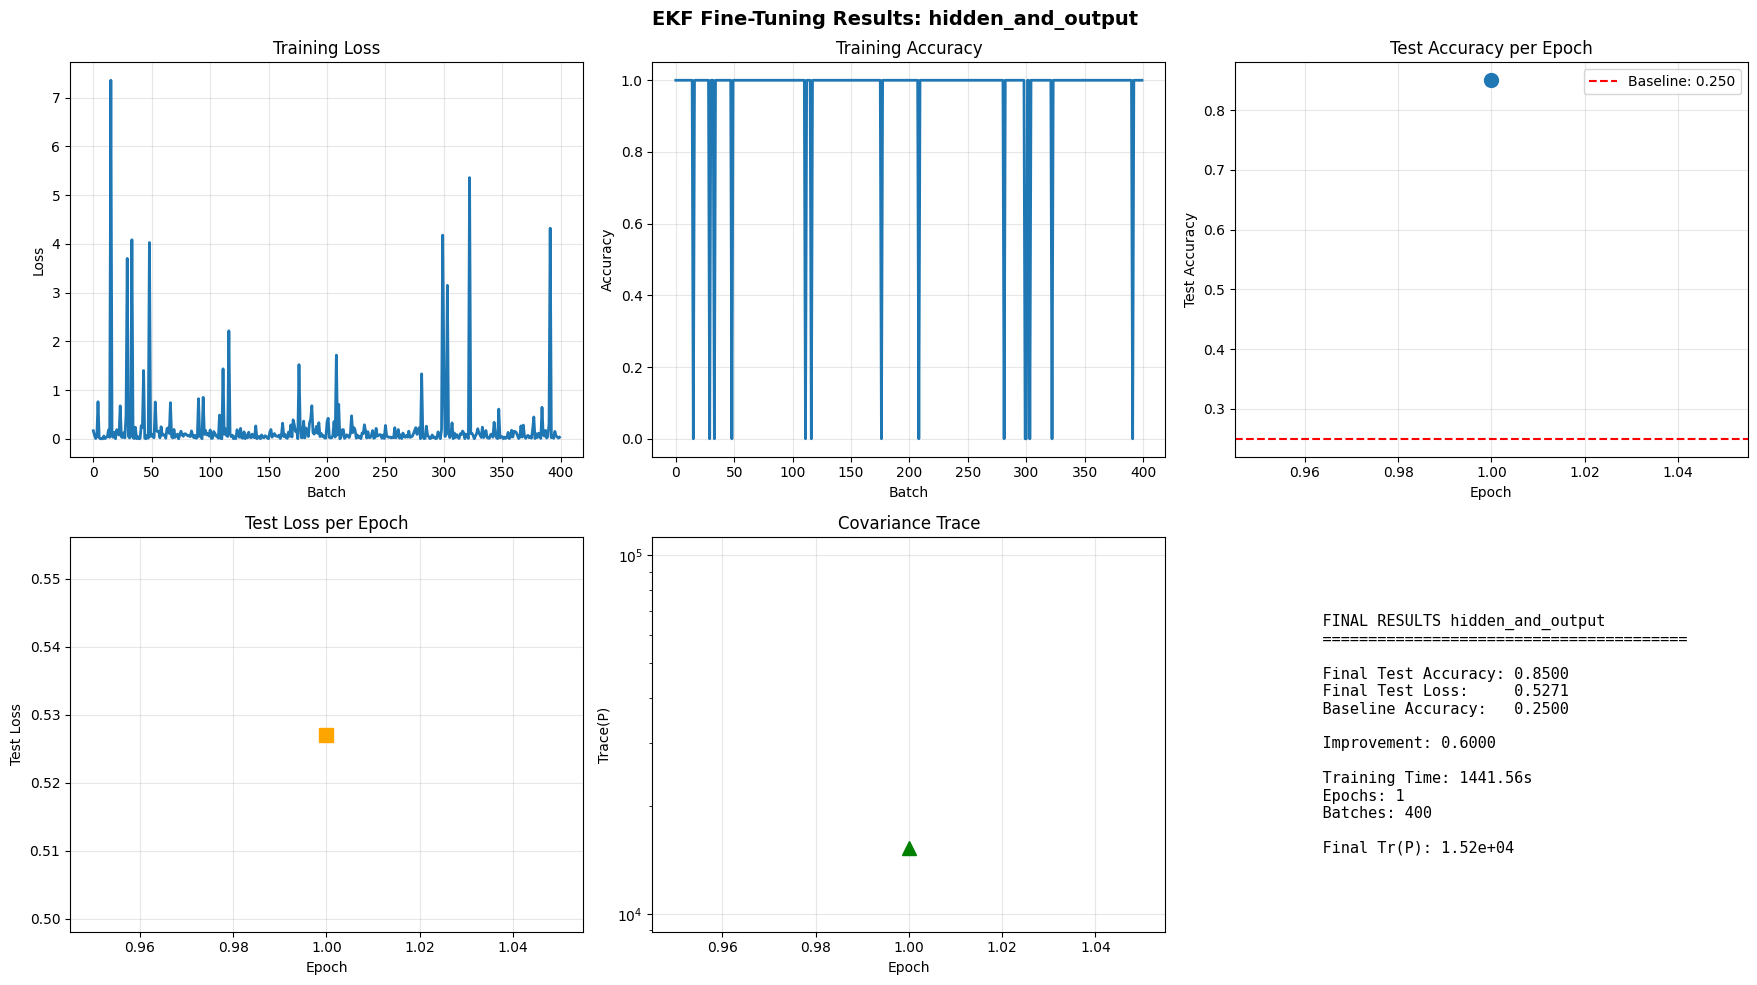

In [19]:
results = ekf_finetune(
    pretrained_model,
    X_train_finetune_shifted, y_train_finetune,
    X_test_finetune_shifted, y_test_finetune,
    training_scope=config.ekf_training_scope
)

print(f"\n{'='*80}")
print(f"FINAL RESULTS")
print(f"{'='*80}")
print(f"Training scope: {config.ekf_training_scope}")
print(f"Final test accuracy: {results['final_test_acc']:.4f}")
print(f"Final test loss: {results['final_test_loss']:.4f}")
print(f"Improvement: {(results['final_test_acc'] - baseline_acc):.4f}")
print(f"Training time: {results['training_time']:.2f}s")

plot_results(results, baseline_acc, title_suffix=config.ekf_training_scope)